# Imports

In [47]:
# ── Standard library ──
import os, json, time, gc, random

# ── Third-party ──
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output

# ── scikit-learn metrics ──
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

# ── TensorFlow / Keras ──
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization,
                                     GlobalAveragePooling2D, Layer)
from tensorflow.keras.applications import InceptionV3, EfficientNetB3, ConvNeXtLarge
from tensorflow.keras.applications.convnext import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback
from tensorflow.keras.optimizers import Adam, SGD

# Config

In [45]:
# memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Dynamic GPU memory growth enabled.")
    except RuntimeError as e:
        print("Failed to set memory growth:", e)

tf.config.optimizer.set_jit(False)
print("XLA JIT disabled.")

IMG_SIZE = (224, 224)
BATCH_SIZE = 8                 
EPOCHS = 50                    
NUM_FOLDS = 5
KFOLD_ROOT = "../../../../PlantCLEF 2015 Dataset/kfold_dataset/"
PROGRESS_FILE = "convnext_training_progress.json"
METRICS_FILE = "convnext_model_metrics.json"
MODEL_TMPL = "convnext_kfold_model_{}.h5"

if not os.path.exists("class_indices.json"):
    ref_dir = os.path.join(KFOLD_ROOT, "fold_1", "train")
    if not os.path.isdir(ref_dir):
        raise FileNotFoundError(f"'{ref_dir}' not found. Check KFOLD_ROOT in the Config cell.")
    class_names = sorted(c for c in os.listdir(ref_dir) if os.path.isdir(os.path.join(ref_dir, c)))
    with open("class_indices.json", "w") as f:
        json.dump({n: i for i, n in enumerate(class_names)}, f, indent=2)
    print(f"Created class_indices.json from {ref_dir} ({len(class_names)} classes)")

with open("class_indices.json") as f:
    CLASS_INDICES = json.load(f)
CLASS_NAMES = [c for c, _ in sorted(CLASS_INDICES.items(), key=lambda kv: kv[1])]
print(f"Loaded {len(CLASS_NAMES)} classes in fixed training order.")

def make_eval_gen(directory, img_size=IMG_SIZE, batch_size=BATCH_SIZE):
    """Eval generator matching training: ConvNeXt preprocess_input, pinned class order, no shuffle."""
    return ImageDataGenerator(
        preprocessing_function=preprocess_input
    ).flow_from_directory(
        directory, target_size=img_size, batch_size=batch_size,
        class_mode='categorical', shuffle=False, classes=CLASS_NAMES,
    )

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
        print(gpu)
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
    tf.config.optimizer.set_jit(False)

Dynamic GPU memory growth enabled.
XLA JIT disabled.
Loaded 94 classes in fixed training order.
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


# Data Generator

In [7]:
def decode_image(filename, label, img_size=(224, 224)):
    image = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, img_size)
    image = preprocess_input(image)   # <-- replaces  image / 255.0
    return image, label

def get_image_paths_and_labels(data_dir, img_size=(224, 224)):
    class_names = sorted(os.listdir(data_dir))
    class_indices = dict((name, idx) for idx, name in enumerate(class_names))
    file_paths = []
    labels = []

    for class_name in class_names:
        class_dir = os.path.join(data_dir, class_name)
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(('jpg', 'jpeg', 'png')):
                file_paths.append(os.path.join(class_dir, fname))
                label = tf.keras.utils.to_categorical(class_indices[class_name], num_classes=len(class_names))
                labels.append(label)

    return file_paths, labels, len(class_names)

def mixup(image1, label1, image2, label2, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    image = lam * image1 + (1 - lam) * image2
    label = lam * label1 + (1 - lam) * label2
    return image, label

def cutmix(image1, label1, image2, label2, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    h, w, _ = image1.shape
    r_x = np.random.randint(w)
    r_y = np.random.randint(h)
    r_w = int(w * np.sqrt(1 - lam))
    r_h = int(h * np.sqrt(1 - lam))

    x1 = np.clip(r_x - r_w // 2, 0, w)
    y1 = np.clip(r_y - r_h // 2, 0, h)
    x2 = np.clip(r_x + r_w // 2, 0, w)
    y2 = np.clip(r_y + r_h // 2, 0, h)

    image = image1.copy()
    image[y1:y2, x1:x2] = image2[y1:y2, x1:x2]
    lam = 1 - ((x2 - x1) * (y2 - y1) / (h * w))
    label = lam * label1 + (1 - lam) * label2
    return image, label

def apply_mixup_cutmix(images, labels):
    new_images = []
    new_labels = []
    batch_size = len(images)
    for i in range(batch_size):
        j = np.random.randint(0, batch_size)
        image1, label1 = images[i], labels[i]
        image2, label2 = images[j], labels[j]
        if np.random.rand() < 0.5:
            image, label = mixup(image1, label1, image2, label2)
        else:
            image, label = cutmix(image1, label1, image2, label2)
        new_images.append(image)
        new_labels.append(label)
    return tf.stack(new_images), tf.stack(new_labels)

def mixup_cutmix_wrapper(batch_images, batch_labels):
    images, labels = tf.numpy_function(apply_mixup_cutmix, [batch_images, batch_labels], [tf.float32, tf.float32])
    images.set_shape(batch_images.shape)
    labels.set_shape(batch_labels.shape)
    return images, labels

def get_data_generators(train_dir, val_dir, img_size=(224, 224), batch_size=64):
    # --- TRAIN ---
    train_paths, train_labels, num_classes = get_image_paths_and_labels(train_dir, img_size)
    train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
    train_ds = train_ds.shuffle(buffer_size=len(train_paths))
    train_ds = train_ds.map(lambda x, y: decode_image(x, y, img_size), num_parallel_calls=tf.data.AUTOTUNE)
    train_ds = train_ds.batch(batch_size)
    train_ds = train_ds.map(mixup_cutmix_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
    train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

    # --- VALIDATION ---
    val_paths, val_labels, _ = get_image_paths_and_labels(val_dir, img_size)
    val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
    val_ds = val_ds.map(lambda x, y: decode_image(x, y, img_size), num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_ds.batch(batch_size)
    val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

    return train_ds, val_ds


# Model

In [8]:
def build_cnn_model(num_classes, use_label_smoothing=True, phase="head"):
    """
    ConvNeXt-Large backbone, two-phase transfer learning.
      phase="head"     -> backbone FROZEN, train head only, Adam(1e-3)
      phase="finetune" -> backbone TRAINABLE, full fine-tune, SGD(5e-4, momentum, nesterov)
    """
    base = ConvNeXtLarge(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base.trainable = (phase != "head")
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax', dtype='float32')(x)
    model = Model(inputs=base.input, outputs=output)
    loss_fn = tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1 if use_label_smoothing else 0.0)
    optimizer = Adam(learning_rate=1e-3) if phase == "head" \
                else SGD(learning_rate=5e-4, momentum=0.9, nesterov=True)
    model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])
    return model

def unfreeze_for_finetune(model, use_label_smoothing=True, unfreeze_fraction=0.30):
    """Unfreeze only the TOP 30% of layers so fine-tuning fits in 8GB at batch 8.
    Early layers stay frozen -> far fewer gradients/optimizer states -> much less memory.
    This is what stops the Phase-2 OOM on ConvNeXt-Large."""
    layers = model.layers
    cutoff = int(len(layers) * (1 - unfreeze_fraction))
    for i, layer in enumerate(layers):
        layer.trainable = (i >= cutoff)
    loss_fn = tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1 if use_label_smoothing else 0.0)
    model.compile(optimizer=SGD(learning_rate=5e-4, momentum=0.9, nesterov=True),
                  loss=loss_fn, metrics=['accuracy'])
    n_train = sum(l.trainable for l in layers)
    print(f"  Fine-tuning top {n_train}/{len(layers)} layers ({unfreeze_fraction:.0%})")
    return model

# Load Progress

In [9]:
if os.path.exists(PROGRESS_FILE):
    with open(PROGRESS_FILE, "r") as f:
        training_progress = json.load(f)
else:
    training_progress = {}

if os.path.exists(METRICS_FILE):
    with open(METRICS_FILE, "r") as f:
        model_metrics = json.load(f)
else:
    model_metrics = {}

# Live Plots

In [10]:
class LivePlot(Callback):
    """Redraws train/val loss and accuracy curves after every epoch."""
    def __init__(self, fold):
        super().__init__()
        self.fold = fold
        self.history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        for k in self.history:
            if logs.get(k) is not None:
                self.history[k].append(logs[k])

        clear_output(wait=True)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
        e = range(1, len(self.history["loss"]) + 1)

        ax1.plot(e, self.history["loss"], label="train")
        if self.history["val_loss"]:
            ax1.plot(e, self.history["val_loss"], label="val")
        ax1.set_title(f"Fold {self.fold} — Loss"); ax1.set_xlabel("epoch")
        ax1.legend(); ax1.grid(alpha=0.3)

        ax2.plot(e, self.history["accuracy"], label="train")
        if self.history["val_accuracy"]:
            ax2.plot(e, self.history["val_accuracy"], label="val")
        ax2.set_title(f"Fold {self.fold} — Accuracy"); ax2.set_xlabel("epoch")
        ax2.set_ylim(0, 1); ax2.legend(); ax2.grid(alpha=0.3)

        plt.tight_layout(); plt.show()

# Train Each Fold

In [11]:
# Phase budgets
HEAD_EPOCHS = 8      # phase 1: frozen backbone, train head only
FINE_EPOCHS = EPOCHS # phase 2: full fine-tuning (uses EPOCHS from Config = 65)


def combined_metric(val_loss, val_accuracy, weight=0.7):
    return (weight * val_loss) - ((1 - weight) * val_accuracy)


class ComboEarlyStopping(Callback):
    """Stops on a blended val_loss / val_accuracy score and restores best weights.
    Unlike the previous version, this is passed to a SINGLE multi-epoch fit() call,
    so stop_training actually halts training (the old one-epoch-at-a-time loop did not)."""
    def __init__(self, patience=8, weight=0.7, restore_best=True):
        super().__init__()
        self.patience = patience
        self.weight = weight
        self.restore_best = restore_best
        self.wait = 0
        self.best_score = float('inf')
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        score = combined_metric(logs.get('val_loss'), logs.get('val_accuracy'), self.weight)
        if score < self.best_score:
            self.best_score = score
            self.wait = 0
            if self.restore_best:
                self.best_weights = self.model.get_weights()
        else:
            self.wait += 1
            if self.wait >= self.patience:
                print(f"\n[ComboEarlyStopping] triggered at epoch {epoch + 1}")
                self.model.stop_training = True

    def on_train_end(self, logs=None):
        if self.restore_best and self.best_weights is not None:
            self.model.set_weights(self.best_weights)
            print("[ComboEarlyStopping] restored best weights")
        print(f"[ComboEarlyStopping] best combo score: {self.best_score:.4f}")


# === TWO-PHASE TRAINING LOOP ===
for fold in range(1, NUM_FOLDS + 1):
    print(f"\nTraining Fold {fold}")

    tf.keras.backend.clear_session()
    gc.collect()

    train_path = os.path.join(KFOLD_ROOT, f"fold_{fold}", "train")
    val_path   = os.path.join(KFOLD_ROOT, f"fold_{fold}", "val")
    train_gen, val_gen = get_data_generators(train_path, val_path, img_size=IMG_SIZE, batch_size=BATCH_SIZE)

    # Save the authoritative class ordering ONCE, from the training directory.
    # Every later evaluation must load this and pass it as classes=, which
    # permanently prevents the index<->species misalignment seen earlier.
    if not os.path.exists("class_indices.json"):
        class_names = sorted(
            c for c in os.listdir(train_path)
            if os.path.isdir(os.path.join(train_path, c))
        )
        with open("class_indices.json", "w") as f:
            json.dump({n: i for i, n in enumerate(class_names)}, f, indent=2)
        print(f"Saved class_indices.json ({len(class_names)} classes)")

    model_path = MODEL_TMPL.format(fold)
    fold_key = f"kfold_model_{fold}"

    # Per-fold resume: if this fold's model already exists, skip it.
    if os.path.exists(model_path):
        print(f"{model_path} already exists; skipping. Delete it to retrain this fold.")
        continue

    # Number of classes from one batch
    for batch_images, batch_labels in train_gen.take(1):
        num_classes = batch_labels.shape[-1]

    callbacks = [
        ComboEarlyStopping(patience=8, weight=0.7, restore_best=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
        ModelCheckpoint(filepath=model_path, monitor='val_loss', save_best_only=True, verbose=1),
        # LivePlot(fold),
    ]

    t0 = time.time()

    # ---- Phase 1: frozen backbone, train head only ----
    print("  Phase 1: training head (backbone frozen, Adam 1e-3)")
    model = build_cnn_model(num_classes, phase="head")
    model.fit(train_gen, validation_data=val_gen, epochs=HEAD_EPOCHS, verbose=1)

    # ---- Phase 2: unfreeze all, full fine-tuning ----
    print("  Phase 2: full fine-tuning (backbone unfrozen, SGD 5e-4)")
    model = unfreeze_for_finetune(model)
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=FINE_EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    # ---- Final macro metrics on the validation fold ----
    val_preds = model.predict(val_gen)
    y_pred = np.argmax(val_preds, axis=1)
    y_true = []
    for _, batch_labels in val_gen:
        y_true.extend(np.argmax(batch_labels.numpy(), axis=1))
    y_true = np.array(y_true)

    model_metrics[fold_key] = {
        "accuracy":  float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, average='macro', zero_division=0)),
        "recall":    float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
        "f1_score":  float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        "epochs_ran": int(len(history.history['loss'])),
    }
    training_progress[fold_key] = FINE_EPOCHS

    with open(PROGRESS_FILE, "w") as f:
        json.dump(training_progress, f)
    with open(METRICS_FILE, "w") as f:
        json.dump(model_metrics, f, indent=2)

    print(f"Saved {model_path} | {(time.time() - t0)/60:.1f} min | Fold {fold} complete")

    # free this fold's model/graph before the next fold builds (prevents the
    # Phase-2 GPU memory wedge seen when a second full model loads on top)
    del model

print("All folds trained (two-phase).")


Training Fold 1


2026-06-18 07:16:21.646206: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-18 07:16:21.646291: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-18 07:16:21.646354: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-18 07:16:21.985782: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-18 07:16:21.985874: I external/local_xla/xla/stream_executor

convnext_kfold_model_1.h5 already exists; skipping. Delete it to retrain this fold.

Training Fold 2
convnext_kfold_model_2.h5 already exists; skipping. Delete it to retrain this fold.

Training Fold 3
convnext_kfold_model_3.h5 already exists; skipping. Delete it to retrain this fold.

Training Fold 4
convnext_kfold_model_4.h5 already exists; skipping. Delete it to retrain this fold.

Training Fold 5
  Phase 1: training head (backbone frozen, Adam 1e-3)
Epoch 1/8


2026-06-18 07:16:44.130289: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-06-18 07:16:44.692591: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f35bb256b20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-18 07:16:44.692611: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
I0000 00:00:1781749005.598154  184486 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  2/600 [..............................] - ETA: 2:06 - loss: 5.6785 - accuracy: 0.0000e+00   

2026-06-18 07:16:50.424265: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


600/600 [==============================] - 170s 259ms/step - loss: 3.9430 - accuracy: 0.2377 - val_loss: 2.2774 - val_accuracy: 0.6117
Epoch 2/8
600/600 [==============================] - 153s 255ms/step - loss: 3.0632 - accuracy: 0.4548 - val_loss: 1.9762 - val_accuracy: 0.6839
Epoch 3/8
600/600 [==============================] - 152s 252ms/step - loss: 2.8346 - accuracy: 0.5115 - val_loss: 1.8367 - val_accuracy: 0.7332
Epoch 4/8
600/600 [==============================] - 154s 255ms/step - loss: 2.7410 - accuracy: 0.5434 - val_loss: 1.8099 - val_accuracy: 0.7258
Epoch 5/8
600/600 [==============================] - 152s 251ms/step - loss: 2.6379 - accuracy: 0.5755 - val_loss: 1.7607 - val_accuracy: 0.7594
Epoch 6/8
600/600 [==============================] - 152s 252ms/step - loss: 2.5492 - accuracy: 0.6097 - val_loss: 1.7358 - val_accuracy: 0.7586
Epoch 7/8
600/600 [==============================] - 152s 252ms/step - loss: 2.5039 - accuracy: 0.6224 - val_loss: 1.7008 - val_accuracy: 0.

/home/mursalfk/tf-gpu-311/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


600/600 [==============================] - 189s 284ms/step - loss: 2.3332 - accuracy: 0.6831 - val_loss: 1.5750 - val_accuracy: 0.8021 - lr: 5.0000e-04
Epoch 2/50
600/600 [==============================] - ETA: 0s - loss: 2.2776 - accuracy: 0.7012
Epoch 2: val_loss improved from 1.57500 to 1.54392, saving model to convnext_kfold_model_5.h5
600/600 [==============================] - 175s 289ms/step - loss: 2.2776 - accuracy: 0.7012 - val_loss: 1.5439 - val_accuracy: 0.8103 - lr: 5.0000e-04
Epoch 3/50
600/600 [==============================] - ETA: 0s - loss: 2.2184 - accuracy: 0.7219
Epoch 3: val_loss did not improve from 1.54392
600/600 [==============================] - 157s 260ms/step - loss: 2.2184 - accuracy: 0.7219 - val_loss: 1.5491 - val_accuracy: 0.8218 - lr: 5.0000e-04
Epoch 4/50
600/600 [==============================] - ETA: 0s - loss: 2.1960 - accuracy: 0.7273
Epoch 4: val_loss improved from 1.54392 to 1.51787, saving model to convnext_kfold_model_5.h5
600/600 [============

# LayerScale

In [46]:
class LayerScale(Layer):
    def __init__(self, init_values=1e-6, projection_dim=None, **kwargs):
        super().__init__(**kwargs)
        self.init_values = init_values
        self.projection_dim = projection_dim
    def build(self, input_shape):
        dim = self.projection_dim or input_shape[-1]
        self.gamma = self.add_weight(
            name="gamma", shape=(dim,),
            initializer=tf.keras.initializers.Constant(self.init_values),
            trainable=True)
    def call(self, x):
        return x * self.gamma
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"init_values": self.init_values,
                    "projection_dim": self.projection_dim})
        return cfg

# Evaluating Models (Single Model Cross Validation)

## Classification Report

In [17]:
fold_summary = []
for fold in range(1, 6):
    model_path = f"convnext_kfold_model_{fold}.h5"
    if not os.path.exists(model_path):
        print(f"Fold {fold}: {model_path} not found, skipping.")
        continue
    val_path = os.path.join(KFOLD_ROOT, f"fold_{fold}", "val")
    val_gen = make_eval_gen(val_path)
    model = load_model(model_path, compile=False,
                       custom_objects={"LayerScale": LayerScale})
    preds = model.predict(val_gen, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = val_gen.classes
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    fold_summary.append({"fold": fold, "accuracy": acc, "macro_f1": f1})
    print(f"\nFold {fold} Classification Report  (accuracy={acc:.4f}, macro-F1={f1:.4f})\n")
    report = classification_report(
        y_true, y_pred,
        labels=list(range(len(CLASS_NAMES))),
        target_names=CLASS_NAMES,
        output_dict=True, zero_division=0
    )
    print(classification_report(
        y_true, y_pred,
        labels=list(range(len(CLASS_NAMES))),
        target_names=CLASS_NAMES, zero_division=0
    ))
    pd.DataFrame(report).transpose().to_csv(f"classification_report_fold_{fold}.csv")
    print(f"saved -> classification_report_fold_{fold}.csv")

summary_df = pd.DataFrame(fold_summary)
summary_df.loc["mean"] = ["mean", summary_df["accuracy"].mean(), summary_df["macro_f1"].mean()]
summary_df.loc["std"]  = ["std",  summary_df["accuracy"].std(),  summary_df["macro_f1"].std()]
summary_df.to_csv("cv_summary.csv", index=False)
print("\n=== Cross-validation summary ===")
print(summary_df.to_string(index=False))

Found 1155 images belonging to 94 classes.

Fold 1 Classification Report  (accuracy=0.8381, macro-F1=0.8389)

                                              precision    recall  f1-score   support

                      Achillea_millefolium_L       1.00      0.83      0.91        12
                     Aegopodium_podagraria_L       0.79      0.92      0.85        12
                        Agrostemma_githago_L       0.92      1.00      0.96        12
         Ailanthus_altissima_(Mill.)_Swingle       0.92      1.00      0.96        12
Alliaria_petiolata_(M.Bieb.)_Cavara_&_Grande       0.82      0.75      0.78        12
                       Amaranthus_deflexus_L       0.86      1.00      0.92        12
                   Ambrosia_artemisiifolia_L       0.92      0.85      0.88        13
                             Arctium_lappa_L       0.79      0.85      0.81        13
                  Arctium_minus_(Hill)_Bernh       0.75      0.75      0.75        12
                        Artem

## Accuracy Evaluation

=== 5-Fold Cross-Validation Summary ===
  accuracy: 0.8646 ± 0.0101
 precision: 0.8764 ± 0.0088
    recall: 0.8647 ± 0.0105
  f1_score: 0.8646 ± 0.0100


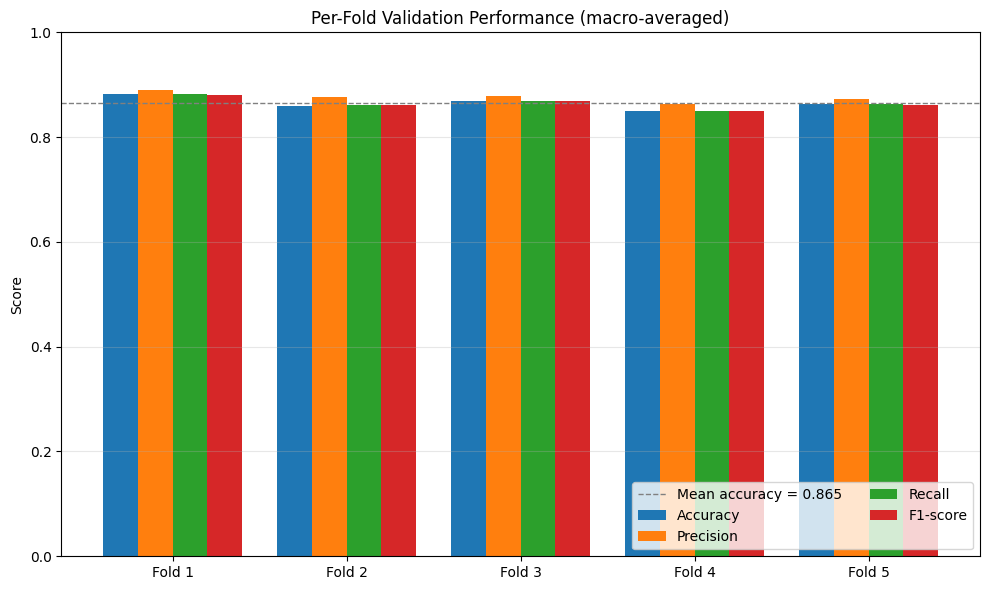


Saved: per_fold_metrics.png  and  cv_summary_table.csv
        accuracy  precision  recall  f1_score
Fold 1    0.8814     0.8908  0.8821    0.8811
Fold 2    0.8601     0.8763  0.8606    0.8607
Fold 3    0.8680     0.8786  0.8683    0.8683
Fold 4    0.8506     0.8639  0.8500    0.8507
Fold 5    0.8629     0.8723  0.8626    0.8622
Mean      0.8646     0.8764  0.8647    0.8646
Std       0.0113     0.0098  0.0118    0.0112


In [19]:
# === Load the per-fold summary metrics ===
with open("convnext_model_metrics.json") as f:
    metrics = json.load(f)

folds = list(metrics.keys())                       # kfold_model_1 ... 5
fold_labels = [f"Fold {i+1}" for i in range(len(folds))]
acc  = [metrics[k]["accuracy"]  for k in folds]
prec = [metrics[k]["precision"] for k in folds]
rec  = [metrics[k]["recall"]    for k in folds]
f1   = [metrics[k]["f1_score"]  for k in folds]

# === Cross-validation summary (mean ± std) ===
def mean_std(v): return np.mean(v), np.std(v)
summary = {
    "accuracy":  mean_std(acc),
    "precision": mean_std(prec),
    "recall":    mean_std(rec),
    "f1_score":  mean_std(f1),
}
print("=== 5-Fold Cross-Validation Summary ===")
for k, (m, s) in summary.items():
    print(f"{k:>10}: {m:.4f} ± {s:.4f}")

# === Grouped bar chart: each metric across folds ===
x = np.arange(len(folds))
w = 0.2
plt.figure(figsize=(10, 6))
plt.bar(x - 1.5*w, acc,  w, label="Accuracy")
plt.bar(x - 0.5*w, prec, w, label="Precision")
plt.bar(x + 0.5*w, rec,  w, label="Recall")
plt.bar(x + 1.5*w, f1,   w, label="F1-score")

# dashed line at mean accuracy for reference
plt.axhline(np.mean(acc), ls="--", lw=1, color="gray",
            label=f"Mean accuracy = {np.mean(acc):.3f}")

plt.xticks(x, fold_labels)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Per-Fold Validation Performance (macro-averaged)")
plt.legend(ncol=2, loc="lower right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("per_fold_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

# === Save a clean summary table for the thesis ===
df = pd.DataFrame(metrics).T[["accuracy", "precision", "recall", "f1_score"]]
df.index = fold_labels
df.loc["Mean"] = df.mean()
df.loc["Std"]  = df.iloc[:-1].std()
df.to_csv("cv_summary_table.csv")
print("\nSaved: per_fold_metrics.png  and  cv_summary_table.csv")
print(df.round(4))

## Cross-Validation Summary — Per-Fold Final Metrics

In [29]:
with open("convnext_model_metrics.json") as f:
    metrics = json.load(f)

final_metrics = []
for i in range(1, 6):
    m = metrics[f"kfold_model_{i}"]
    final_metrics.append({
        "Fold": i,
        "Accuracy":   m["accuracy"],
        "Precision":  m["precision"],
        "Recall":     m["recall"],
        "F1":         m["f1_score"],
        "Epochs":     m["epochs_ran"],
    })

df = pd.DataFrame(final_metrics)
print(df.round(4))
print(f"\nMean Acc: {df['Accuracy'].mean():.4f} | "
      f"Mean F1: {df['F1'].mean():.4f}")

   Fold  Accuracy  Precision  Recall      F1  Epochs
0     1    0.8814     0.8908  0.8821  0.8811      38
1     2    0.8601     0.8763  0.8606  0.8607      34
2     3    0.8680     0.8786  0.8683  0.8683      37
3     4    0.8506     0.8639  0.8500  0.8507      40
4     5    0.8629     0.8723  0.8626  0.8622      39

Mean Acc: 0.8646 | Mean F1: 0.8646


## Cross-Fold Aggregated Metrics

In [36]:
NUM_FOLDS = 5
KFOLD_ROOT = "../../../../PlantCLEF 2015 Dataset/kfold_dataset/"
MODEL_PATH_TEMPLATE = "convnext_kfold_model_{}.h5"

all_true, all_pred = [], []

for fold in range(1, NUM_FOLDS + 1):
    print(f"\n📂 Fold {fold}:")
    val_dir = os.path.join(KFOLD_ROOT, f"fold_{fold}", "val")
    val_gen = make_eval_gen(val_dir)          # same preprocessing as everywhere else, shuffle=False

    model = load_model(MODEL_PATH_TEMPLATE.format(fold),
                       compile=False, custom_objects=CUSTOM_OBJECTS)
    preds = model.predict(val_gen, verbose=0) # predict straight from the generator
    del model
    tf.keras.backend.clear_session()
    gc.collect()

    all_true.extend(val_gen.classes)          # labels in generator order (shuffle=False -> aligned)
    all_pred.extend(np.argmax(preds, axis=1))

accuracy  = accuracy_score(all_true, all_pred)
precision = precision_score(all_true, all_pred, average='macro', zero_division=0)
recall    = recall_score(all_true, all_pred, average='macro', zero_division=0)
f1        = f1_score(all_true, all_pred, average='macro', zero_division=0)

print("\n📊 Cross-Fold Aggregated Metrics")
print(f"✅ Accuracy : {accuracy:.4f}")
print(f"✅ Precision: {precision:.4f}")
print(f"✅ Recall   : {recall:.4f}")
print(f"✅ F1 Score : {f1:.4f}")


📂 Fold 1:
Found 1155 images belonging to 94 classes.

📂 Fold 2:
Found 1165 images belonging to 94 classes.

📂 Fold 3:
Found 1182 images belonging to 94 classes.

📂 Fold 4:
Found 1198 images belonging to 94 classes.

📂 Fold 5:
Found 1218 images belonging to 94 classes.

📊 Cross-Fold Aggregated Metrics
✅ Accuracy : 0.8270
✅ Precision: 0.8328
✅ Recall   : 0.8269
✅ F1 Score : 0.8278


## Confusion Metrices per Fold


Fold 1
Found 1155 images belonging to 94 classes.


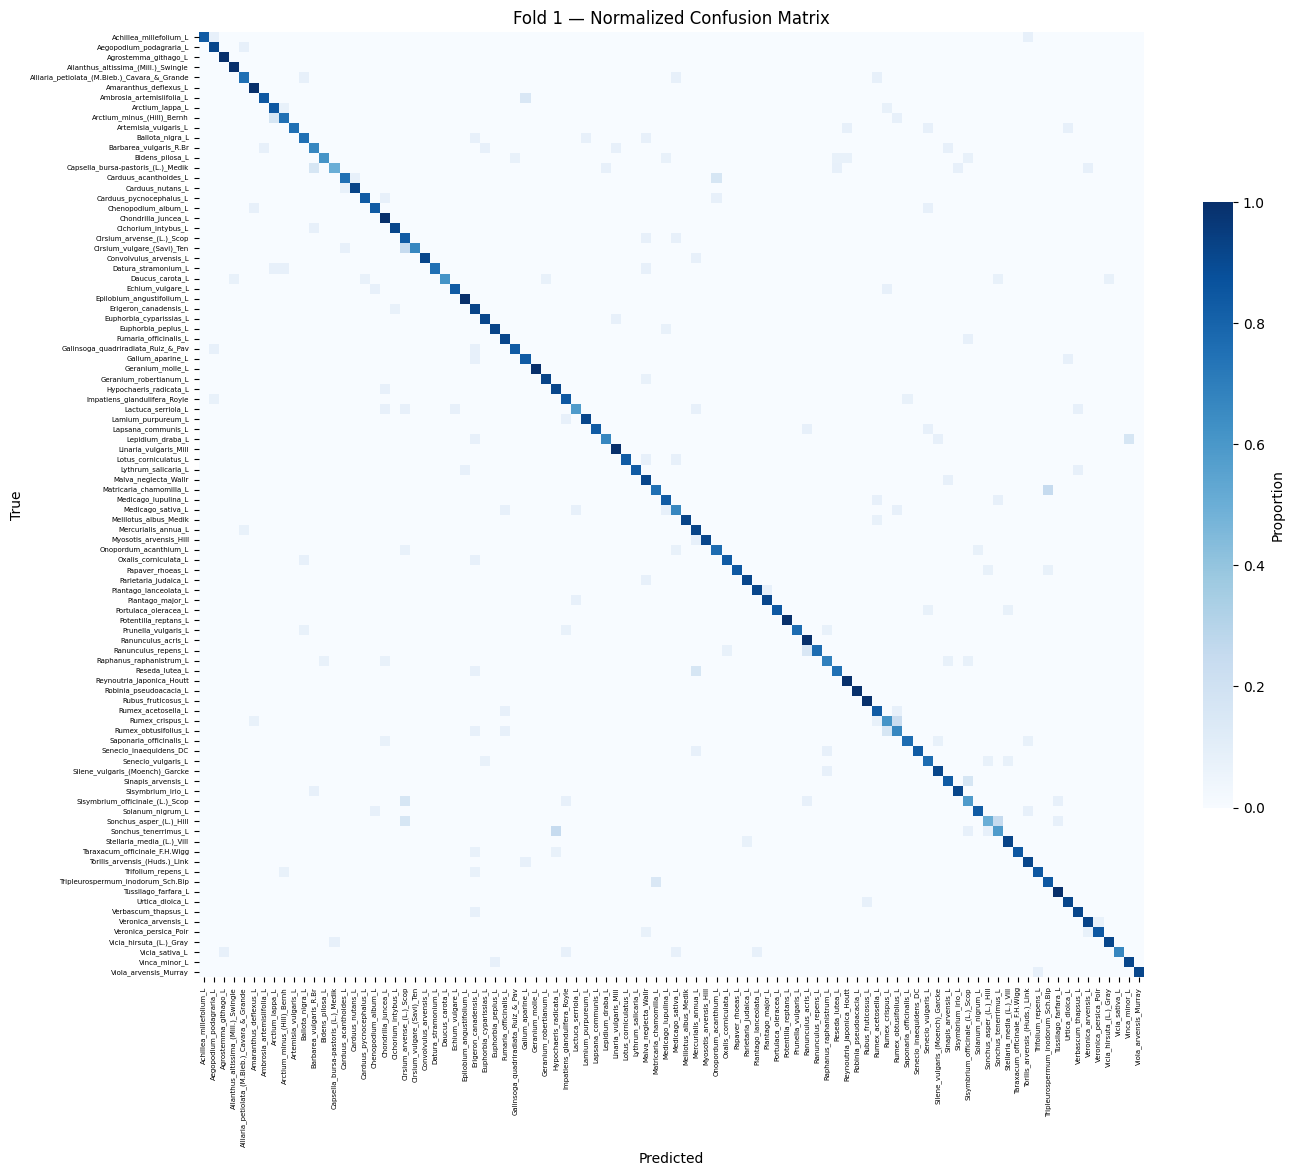

Fold 1 done -> confusion_matrix_per_fold/confusion_matrix_fold_1.png

Fold 2
Found 1165 images belonging to 94 classes.


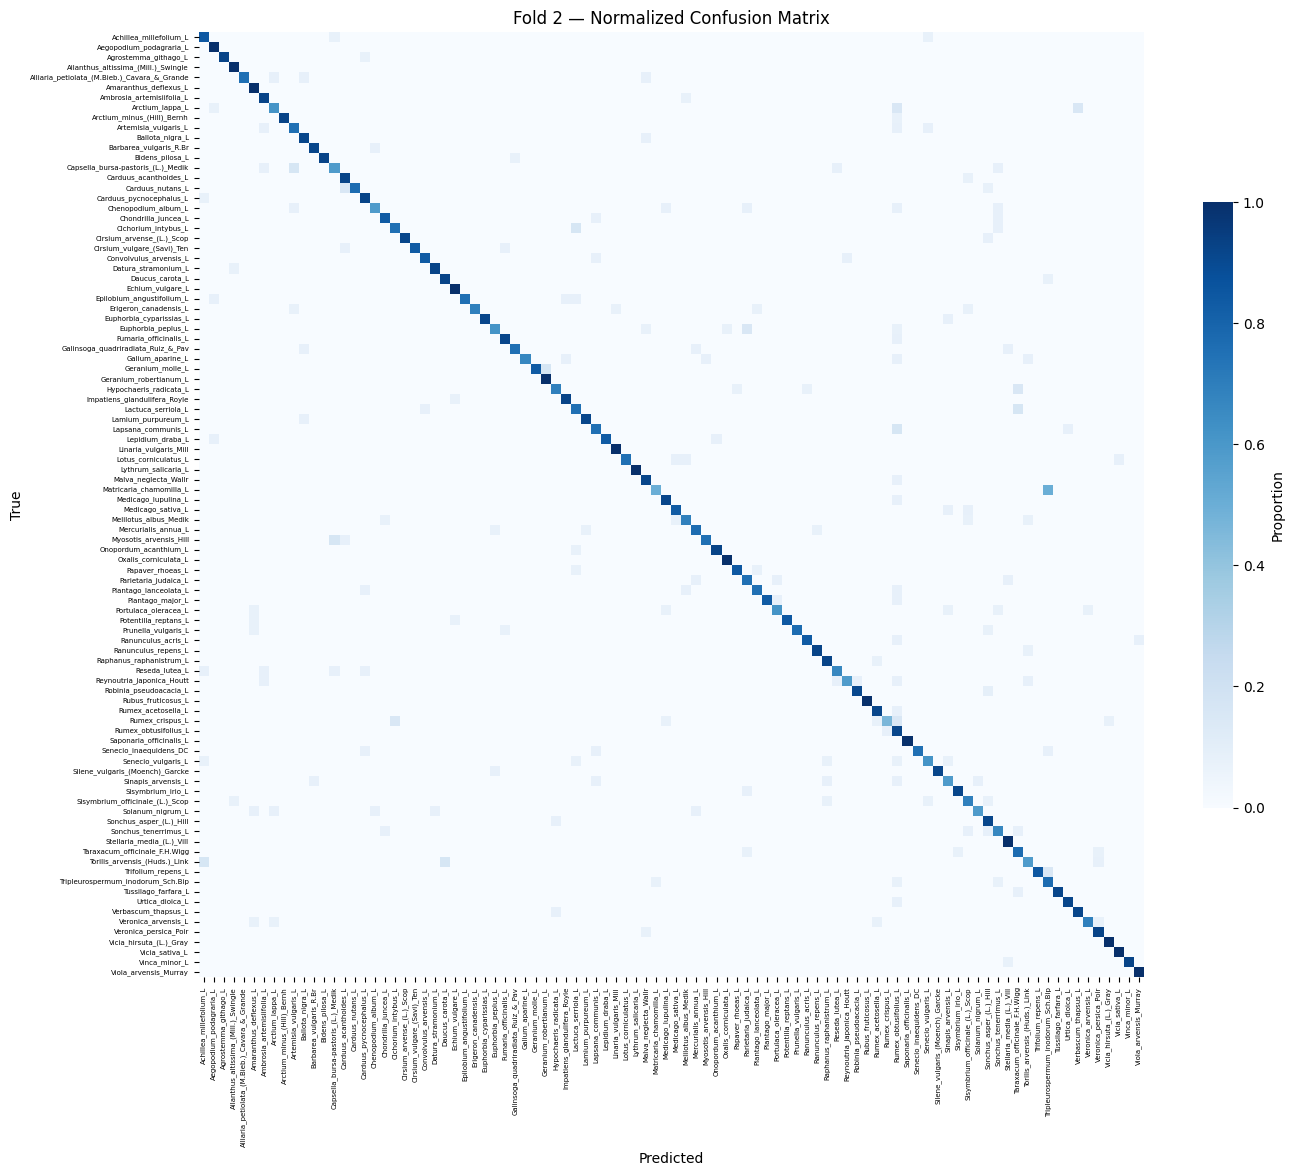

Fold 2 done -> confusion_matrix_per_fold/confusion_matrix_fold_2.png

Fold 3
Found 1182 images belonging to 94 classes.


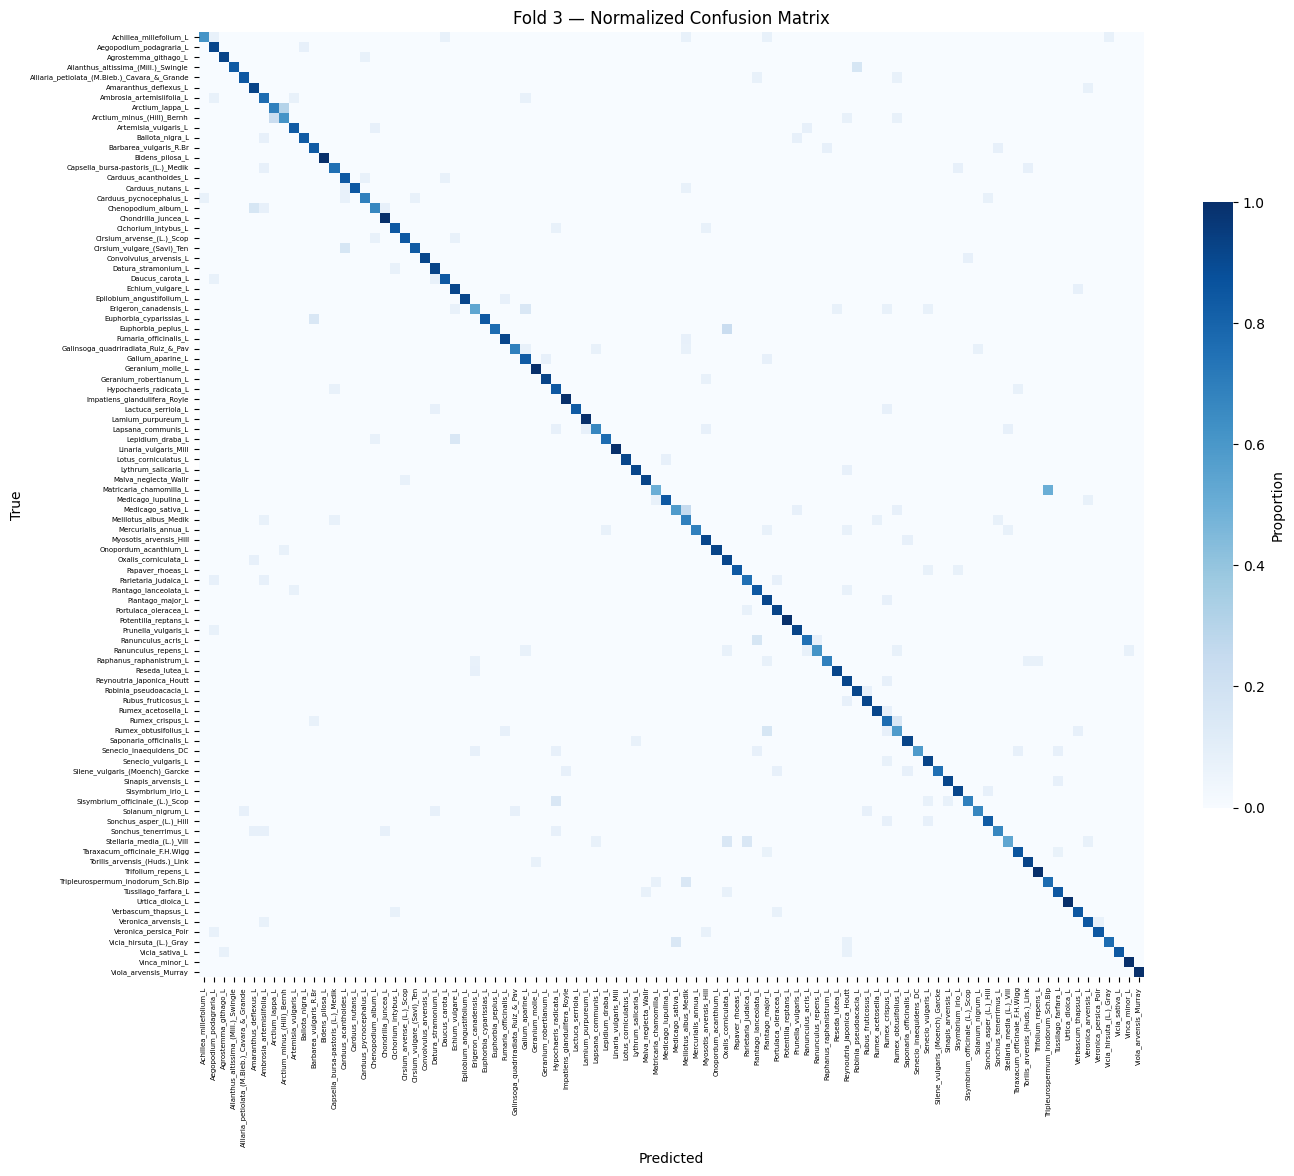

Fold 3 done -> confusion_matrix_per_fold/confusion_matrix_fold_3.png

Fold 4
Found 1198 images belonging to 94 classes.


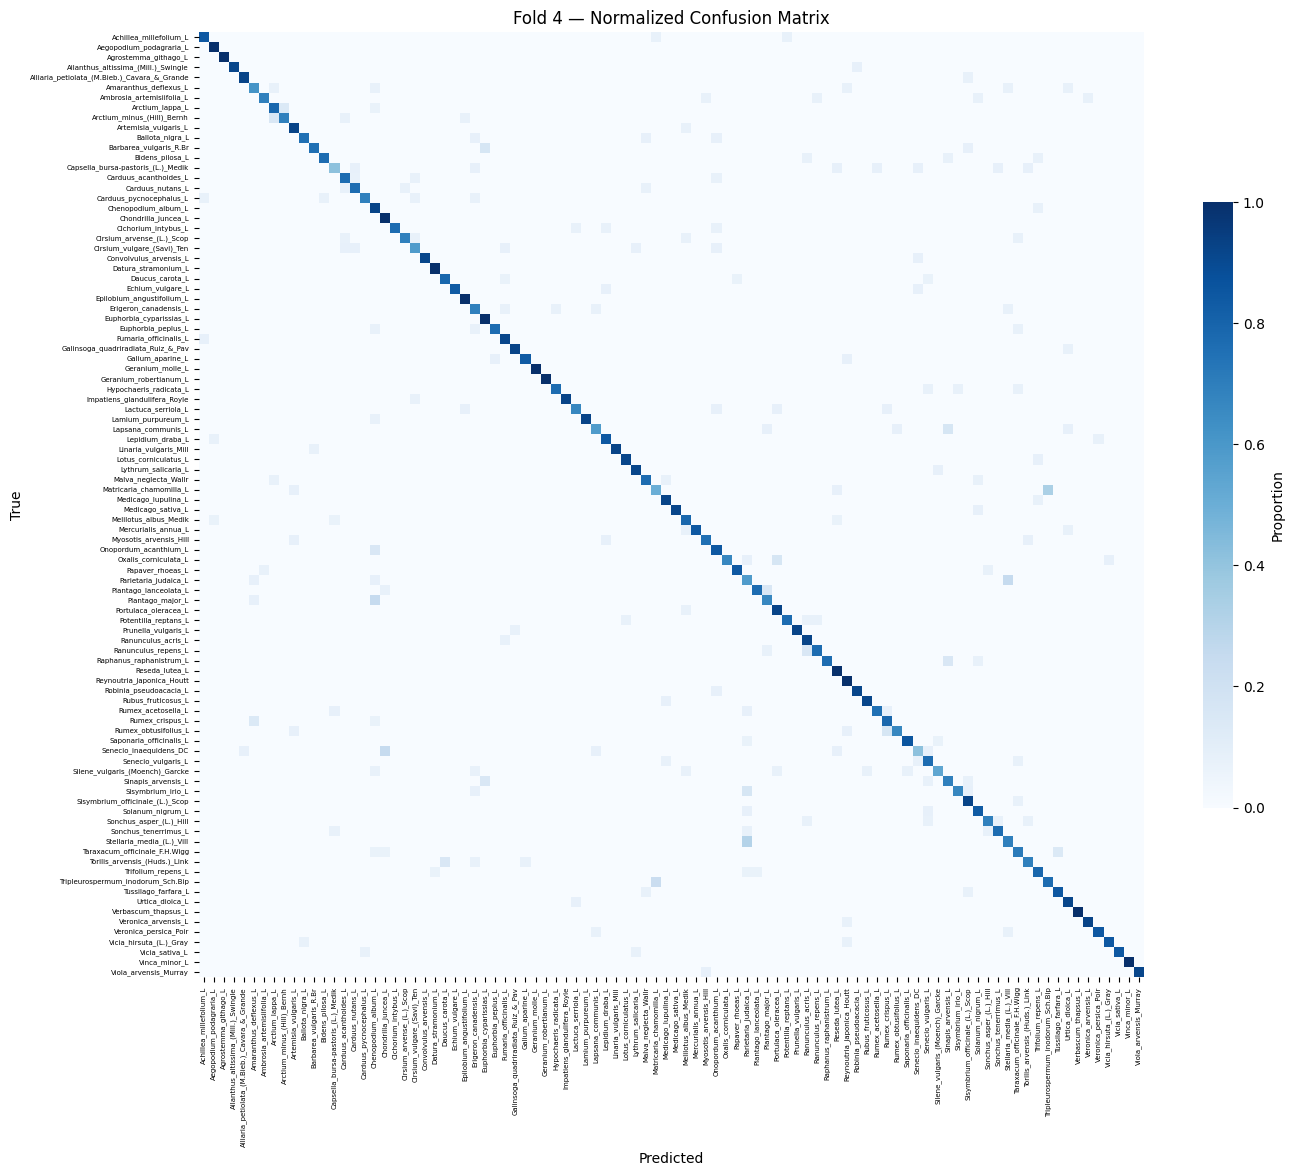

Fold 4 done -> confusion_matrix_per_fold/confusion_matrix_fold_4.png

Fold 5
Found 1218 images belonging to 94 classes.


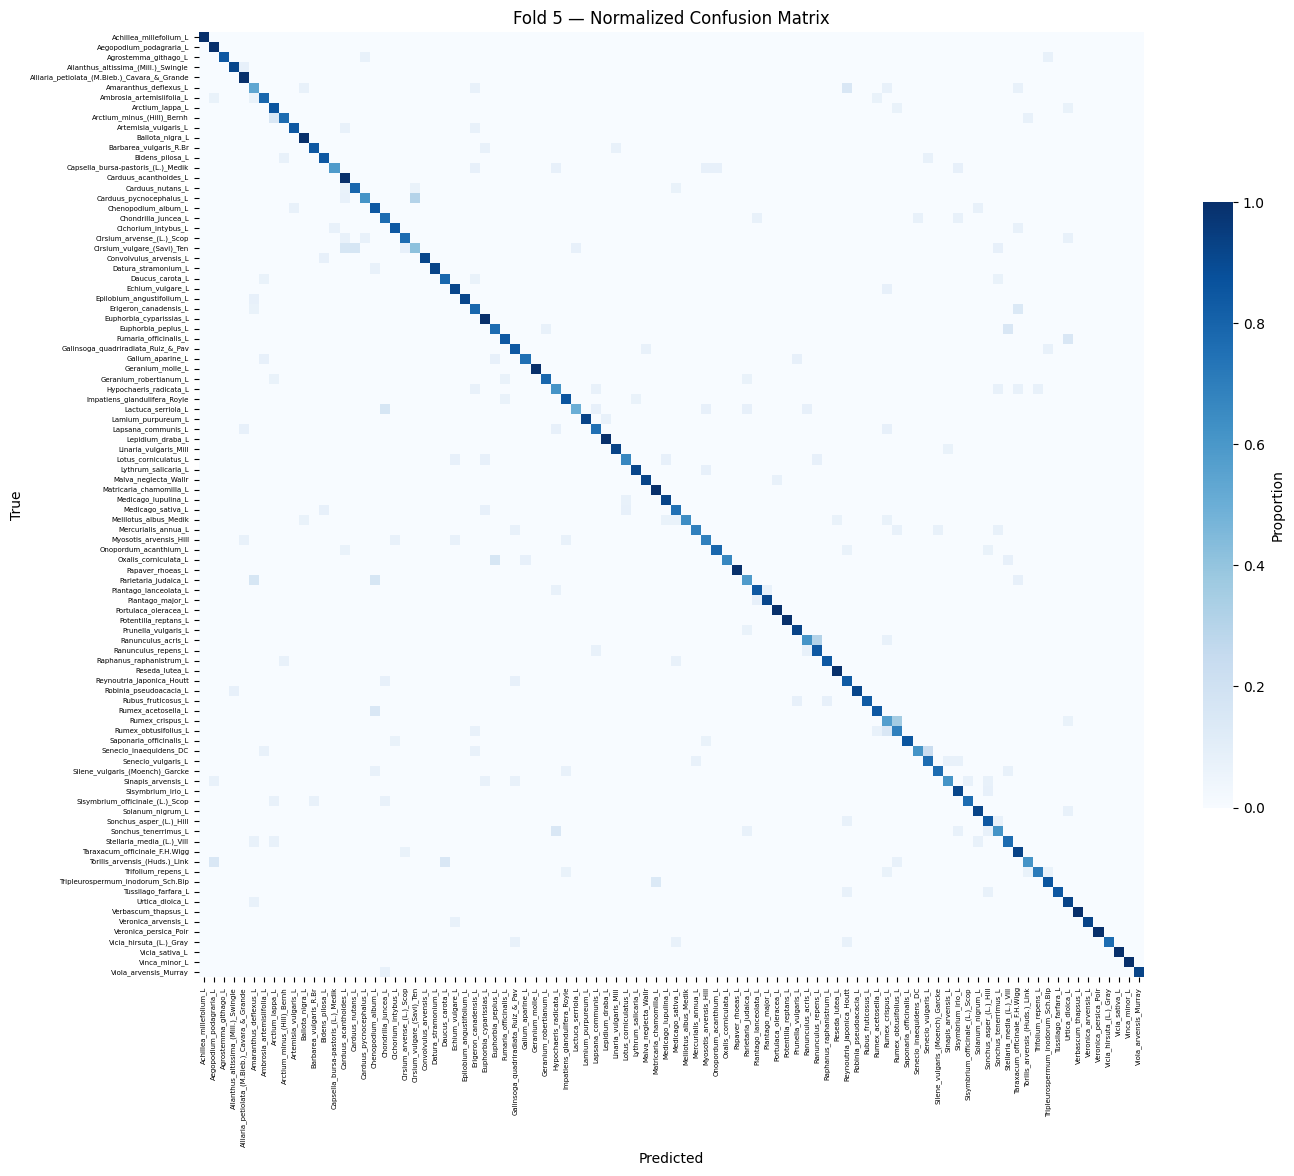

Fold 5 done -> confusion_matrix_per_fold/confusion_matrix_fold_5.png


In [23]:
# --- ConvNeXt custom layer so .h5 models load on this TF build ---
class LayerScale(Layer):
    def __init__(self, init_values=1e-6, projection_dim=None, **kwargs):
        super().__init__(**kwargs)
        self.init_values = init_values
        self.projection_dim = projection_dim
    def build(self, input_shape):
        dim = self.projection_dim or input_shape[-1]
        self.gamma = self.add_weight(
            name="gamma", shape=(dim,),
            initializer=tf.keras.initializers.Constant(self.init_values),
            trainable=True)
    def call(self, x):
        return x * self.gamma
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"init_values": self.init_values,
                    "projection_dim": self.projection_dim})
        return cfg

CUSTOM_OBJECTS = {"LayerScale": LayerScale}

# normalize=True shows row-wise proportions (better for 94 imbalanced classes);
# set False if you want raw counts.
NORMALIZE = True

OUTPUT_DIR = "confusion_matrix_per_fold"
os.makedirs(OUTPUT_DIR, exist_ok=True)

for fold in range(1, NUM_FOLDS + 1):
    print(f"\nFold {fold}")
    tf.keras.backend.clear_session()
    gc.collect()

    model_path = f"convnext_kfold_model_{fold}.h5"
    if not os.path.exists(model_path):
        print(f"Fold {fold}: {model_path} not found, skipping.")
        continue

    val_gen = make_eval_gen(os.path.join(KFOLD_ROOT, f"fold_{fold}", "val"))
    model = load_model(model_path, compile=False, custom_objects=CUSTOM_OBJECTS)

    y_pred = np.argmax(model.predict(val_gen, verbose=0), axis=1)
    y_true = val_gen.classes

    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASS_NAMES))))
    if NORMALIZE:
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_plot = np.divide(cm, row_sums, where=row_sums != 0)
        title = f"Fold {fold} — Normalized Confusion Matrix"
    else:
        cm_plot = cm
        title = f"Fold {fold} — Confusion Matrix (counts)"

    # plot and SAVE before show, so the file is never blank
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cm_plot, annot=False, cmap='Blues',
        vmin=0, vmax=1 if NORMALIZE else None,
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        square=True,
        cbar_kws={"shrink": 0.6, "label": "Proportion" if NORMALIZE else "Count"},
    )
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(title)
    plt.xticks(rotation=90, fontsize=5)
    plt.yticks(rotation=0, fontsize=5)
    plt.tight_layout()

    png_path = os.path.join(OUTPUT_DIR, f"confusion_matrix_fold_{fold}.png")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")   # SAVE first
    plt.show()                                            # then display
    plt.close()                                           # free the figure

    # also save raw counts for the results chapter
    np.save(os.path.join(OUTPUT_DIR, f"confusion_matrix_fold_{fold}.npy"), cm)

    del model
    print(f"Fold {fold} done -> {png_path}")

# Evaluation B — ensemble on held-out test set:

## Borda Count

TEST_DIR resolves to: /mnt/d/Study/Sapienza/Thesis/Main/PlantCLEF 2015 Dataset/weed_only_dataset/organized_test_dataset
exists: True
Found 4971 images belonging to 94 classes.
Test images: 4971 across 94 classes
622/622 [==============================] - 65s 99ms/step

Borda Count
  acc=0.7612  P=0.7771  R=0.7526  F1=0.7384


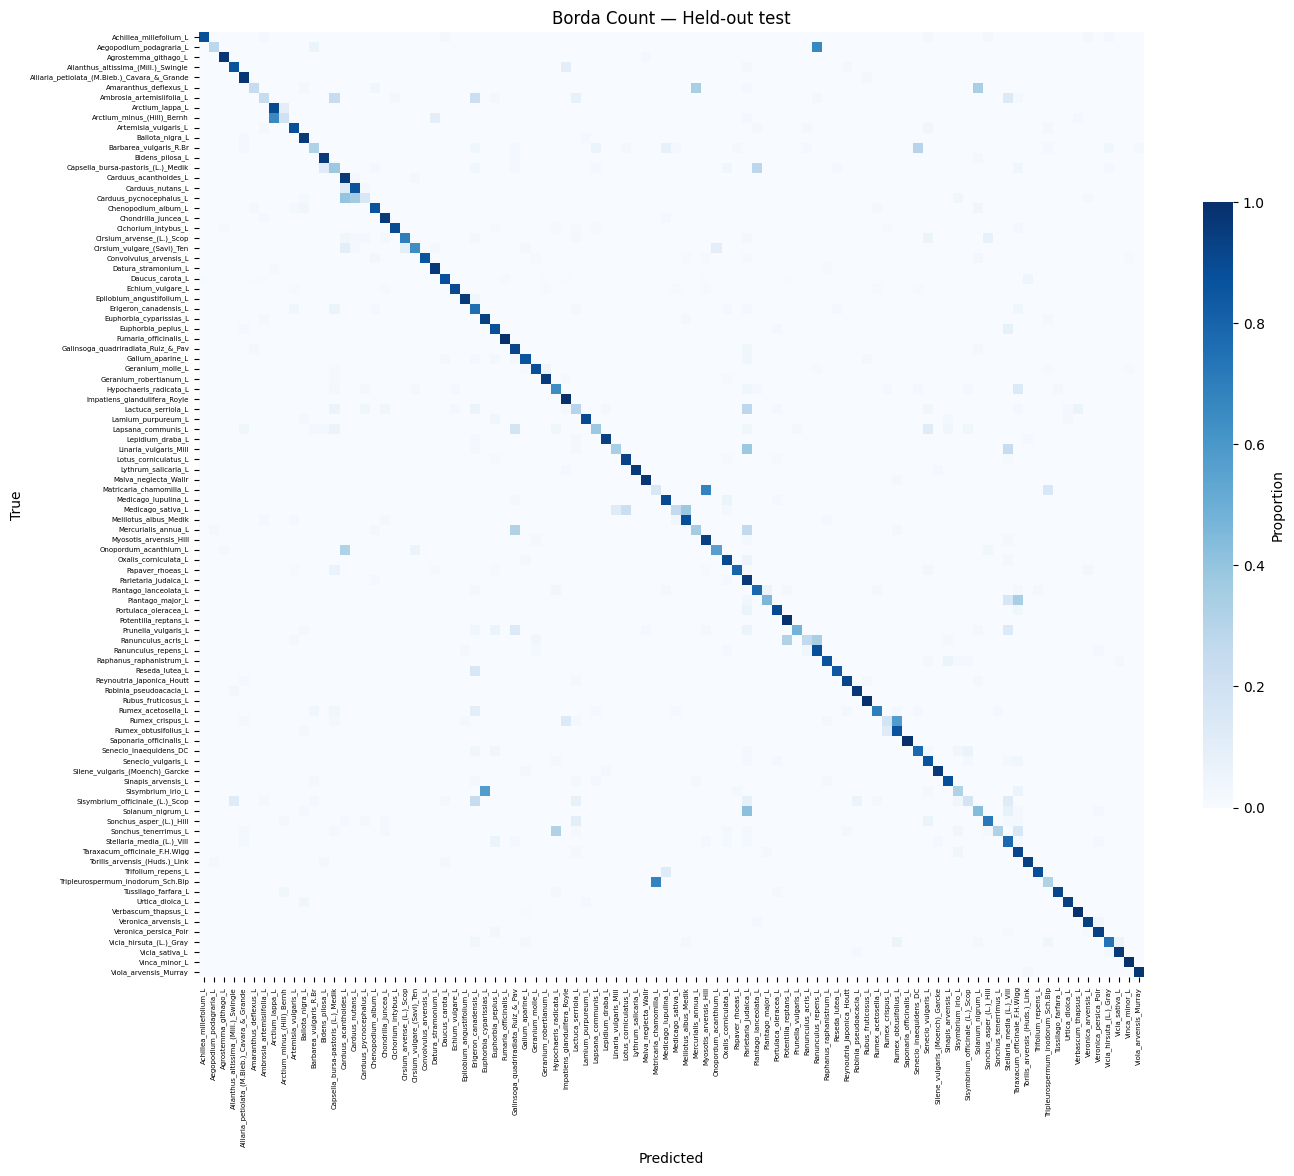


Soft Voting
  acc=0.7632  P=0.7849  R=0.7545  F1=0.7399


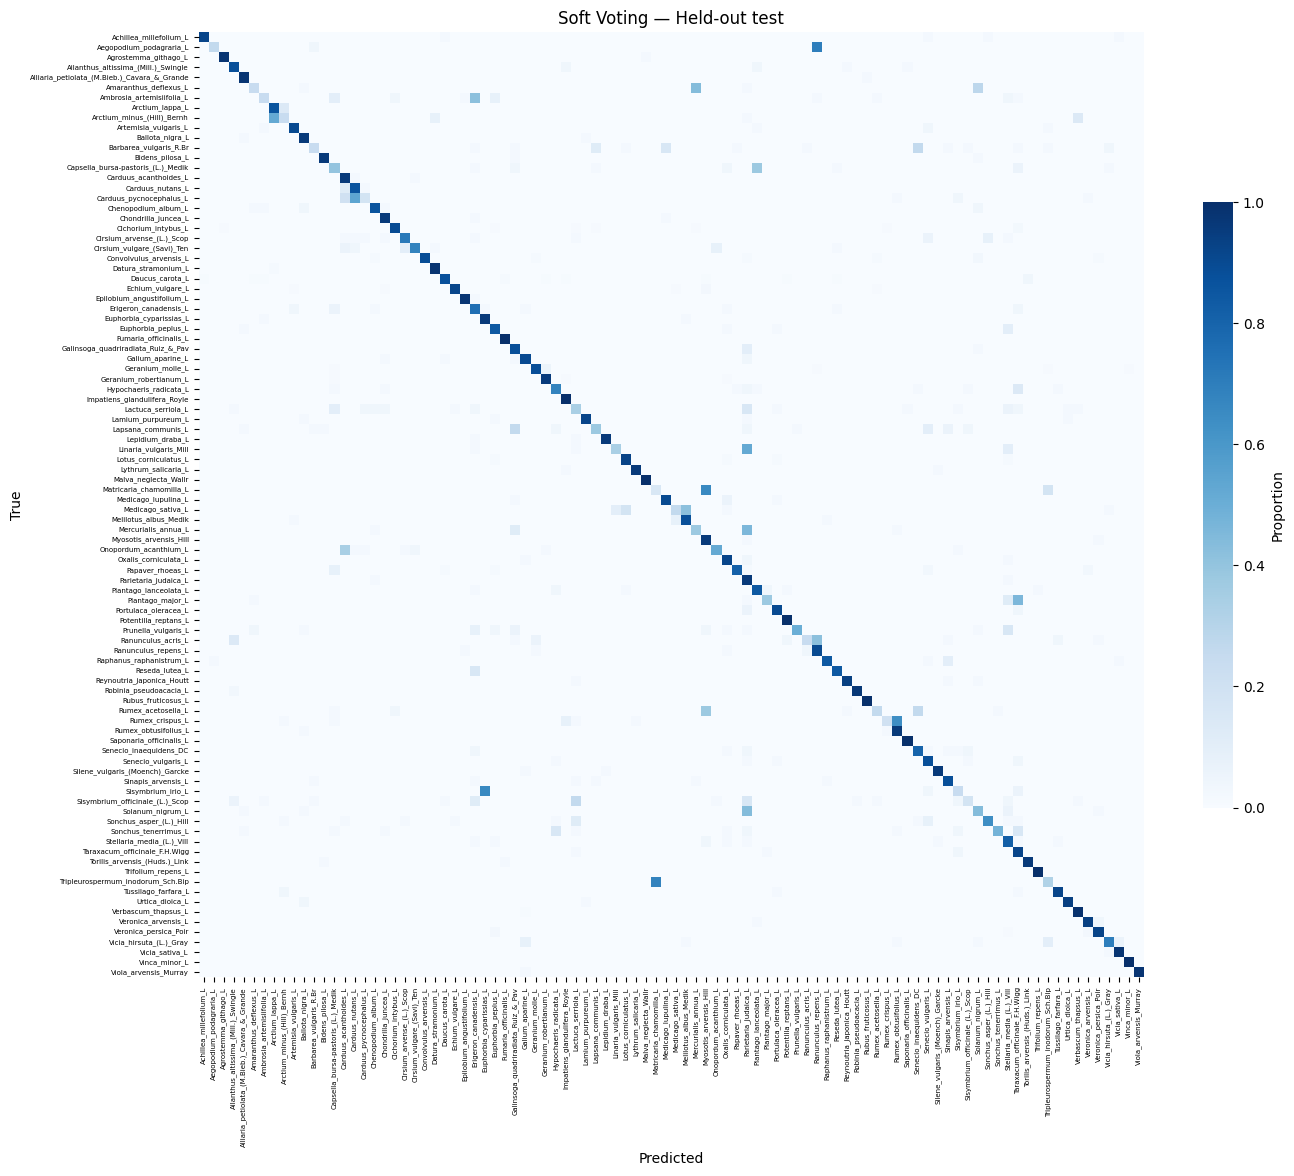


All results + plots saved to: ensemble_results/


In [28]:
CUSTOM_OBJECTS = {"LayerScale": LayerScale}

NUM_FOLDS = 5
OUT = "ensemble_results"
os.makedirs(OUT, exist_ok=True)

# >>> THE HELD-OUT TEST SET (NOT organized_train_dataset) <
TEST_DIR = "../../../../PlantCLEF 2015 Dataset/weed_only_dataset/organized_test_dataset/"
print("TEST_DIR resolves to:", os.path.abspath(TEST_DIR))
print("exists:", os.path.isdir(TEST_DIR))

# --- aligned test generator (preprocess_input + pinned class order, 299x299) ---
test_gen = make_eval_gen(TEST_DIR)
true_labels = test_gen.classes
print(f"Test images: {test_gen.samples} across {len(CLASS_NAMES)} classes")

# Stop early if the test set is empty — otherwise every metric is silently 0/NaN.
if test_gen.samples == 0:
    raise RuntimeError(
        f"No images found under {os.path.abspath(TEST_DIR)}. "
        "Check the path and that it has the structure TEST_DIR/<class_name>/<image>.")

# --- collect probability vectors from all 5 models ---
all_preds = []
for fold in range(1, NUM_FOLDS + 1):
    model = load_model(f"convnext_kfold_model_{fold}.h5", compile=False,
                       custom_objects=CUSTOM_OBJECTS)
    preds = model.predict(test_gen, verbose=1)
    all_preds.append(preds)
    del model
    tf.keras.backend.clear_session(); gc.collect()
all_preds = np.array(all_preds)            # (5, N, 94)

def evaluate(name, y_pred):
    acc  = accuracy_score(true_labels, y_pred)
    prec = precision_score(true_labels, y_pred, average='macro', zero_division=0)
    rec  = recall_score(true_labels, y_pred, average='macro', zero_division=0)
    f1   = f1_score(true_labels, y_pred, average='macro', zero_division=0)
    print(f"\n{name}\n  acc={acc:.4f}  P={prec:.4f}  R={rec:.4f}  F1={f1:.4f}")
    rep = classification_report(true_labels, y_pred, target_names=CLASS_NAMES,
                                zero_division=0, output_dict=True)
    tag = name.lower().replace(" ", "_").replace("/", "_")
    with open(os.path.join(OUT, f"{tag}.json"), "w") as f:
        json.dump(rep, f, indent=2)
    pd.DataFrame(rep).transpose().to_csv(os.path.join(OUT, f"{tag}.csv"))
    # confusion matrix figure (saved before show)
    cm = confusion_matrix(true_labels, y_pred, labels=list(range(len(CLASS_NAMES))))
    row = cm.sum(axis=1, keepdims=True)
    cmn = np.divide(cm, row, where=row != 0)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cmn, cmap='Blues', vmin=0, vmax=1, square=True,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cbar_kws={"shrink": 0.6, "label": "Proportion"})
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"{name} — Held-out test")
    plt.xticks(rotation=90, fontsize=5); plt.yticks(rotation=0, fontsize=5)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT, f"{tag}_confusion.png"), dpi=300, bbox_inches="tight")
    plt.show(); plt.close()
    return dict(accuracy=acc, precision=prec, recall=rec, f1=f1)

# --- Borda count (rank-based) ---
ranks = np.argsort(np.argsort(-all_preds, axis=2), axis=2)
borda_pred = np.argmin(ranks.sum(axis=0), axis=1)
borda = evaluate("Borda Count", borda_pred)

# --- Soft voting / Averaging (mean of probabilities -> argmax) ---
softvote_pred = np.argmax(all_preds.mean(axis=0), axis=1)
softvote = evaluate("Soft Voting", softvote_pred)

# --- summary ---
pd.DataFrame({"Borda": borda, "SoftVoting": softvote}).T.to_csv(
    os.path.join(OUT, "ensemble_summary.csv"))
print(f"\nAll results + plots saved to: {OUT}/")

## Soft-Voting (With Fold)

TEST_DIR resolves to: /mnt/d/Study/Sapienza/Thesis/Main/PlantCLEF 2015 Dataset/weed_only_dataset/organized_test_dataset
exists: True
Found 4971 images belonging to 94 classes.
Test images: 4971 across 94 classes
622/622 [==============================] - 67s 102ms/step

Borda Count
  acc=0.7612  P=0.7771  R=0.7526  F1=0.7384


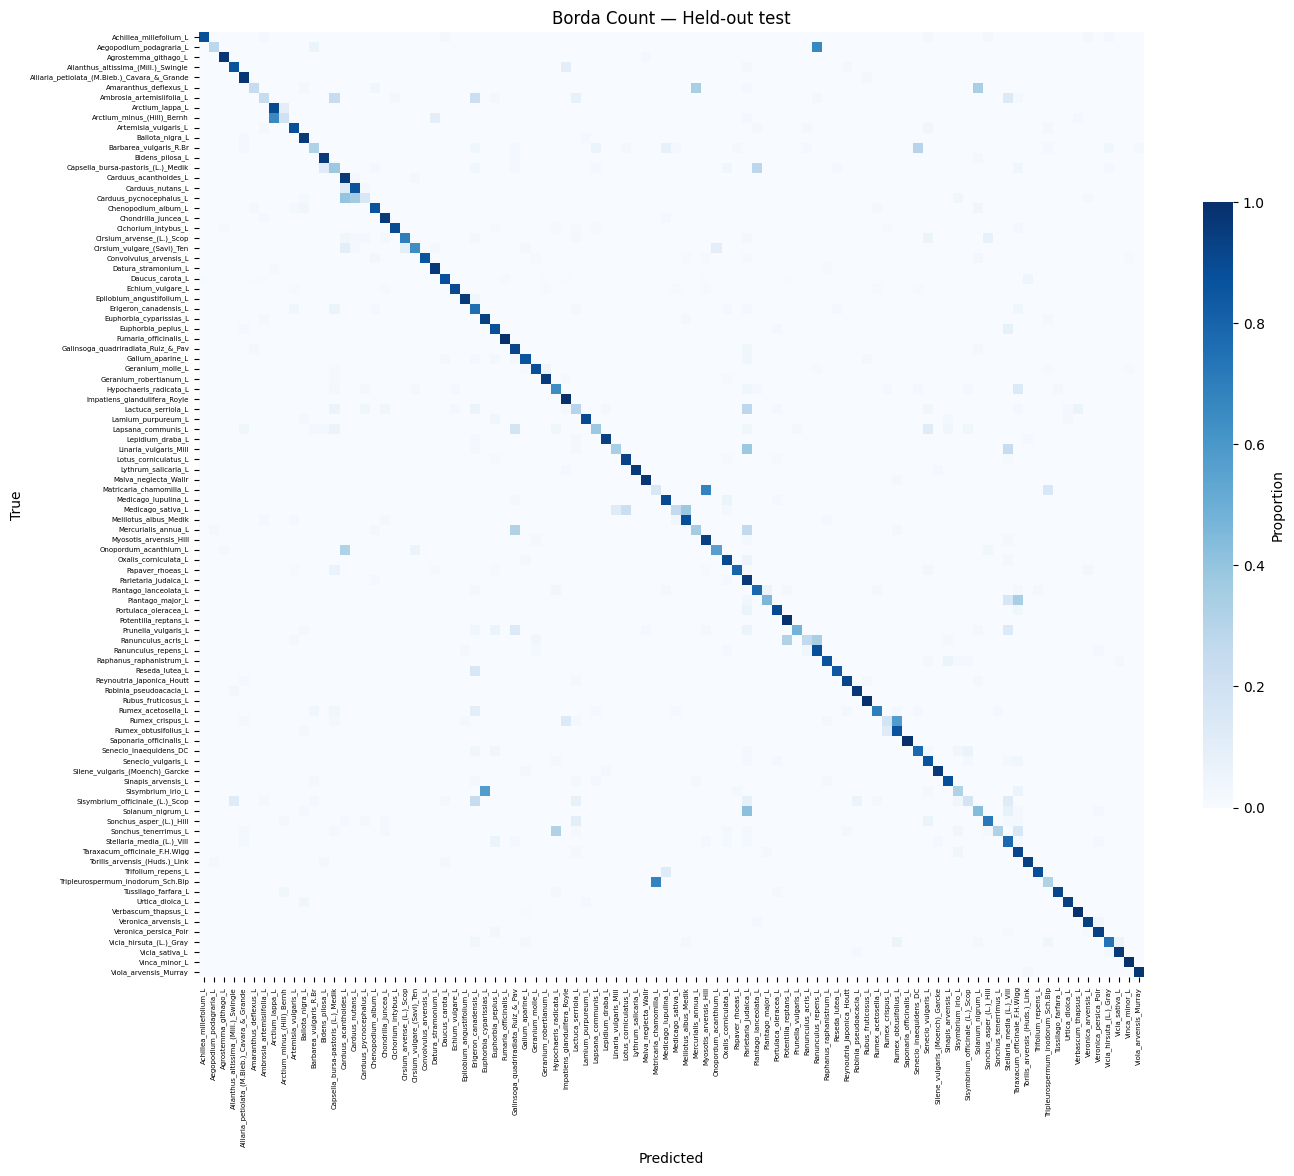


Soft Voting
  acc=0.7632  P=0.7849  R=0.7545  F1=0.7399


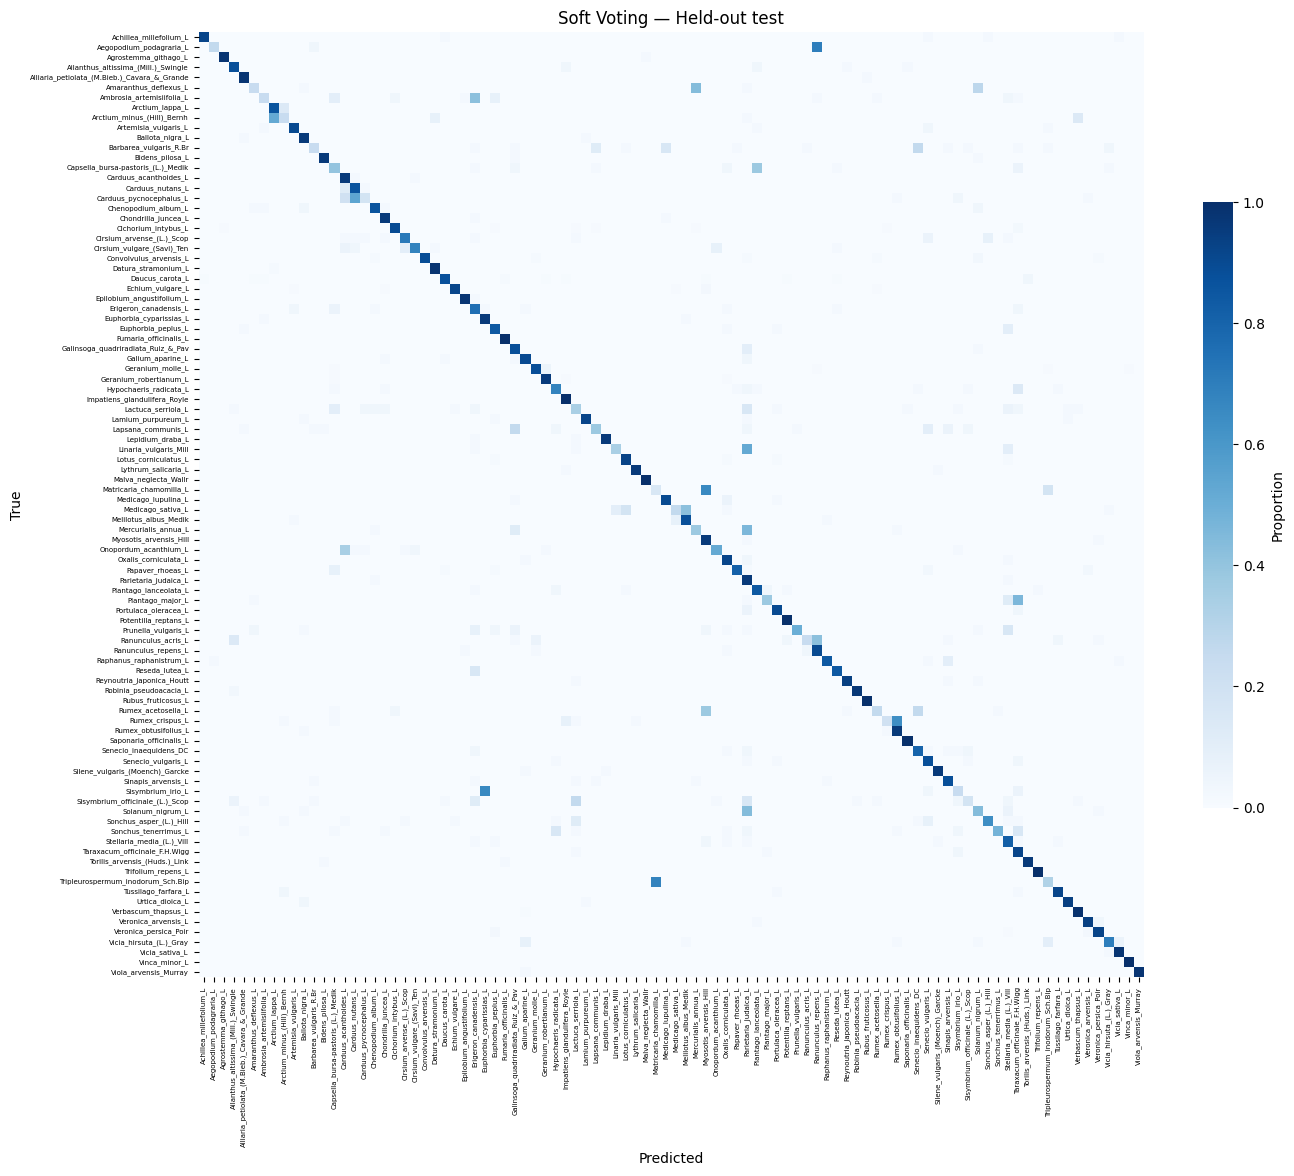


All results + plots saved to: ensemble_results/


In [34]:
CUSTOM_OBJECTS = {"LayerScale": LayerScale}

NUM_FOLDS = 5
OUT = "ensemble_results"
os.makedirs(OUT, exist_ok=True)

# >>> THE HELD-OUT TEST SET (NOT organized_train_dataset) <
TEST_DIR = "../../../../PlantCLEF 2015 Dataset/weed_only_dataset/organized_test_dataset/"
print("TEST_DIR resolves to:", os.path.abspath(TEST_DIR))
print("exists:", os.path.isdir(TEST_DIR))

# --- aligned test generator (preprocess_input + pinned class order, 299x299) ---
test_gen = make_eval_gen(TEST_DIR)
true_labels = test_gen.classes
print(f"Test images: {test_gen.samples} across {len(CLASS_NAMES)} classes")

# Stop early if the test set is empty — otherwise every metric is silently 0/NaN.
if test_gen.samples == 0:
    raise RuntimeError(
        f"No images found under {os.path.abspath(TEST_DIR)}. "
        "Check the path and that it has the structure TEST_DIR/<class_name>/<image>.")

# --- collect probability vectors from all 5 models ---
all_preds = []
for fold in range(1, NUM_FOLDS + 1):
    model = load_model(f"convnext_kfold_model_{fold}.h5", compile=False,
                       custom_objects=CUSTOM_OBJECTS)
    preds = model.predict(test_gen, verbose=1)
    all_preds.append(preds)
    del model
    tf.keras.backend.clear_session(); gc.collect()
all_preds = np.array(all_preds)            # (5, N, 94)

def evaluate(name, y_pred):
    acc  = accuracy_score(true_labels, y_pred)
    prec = precision_score(true_labels, y_pred, average='macro', zero_division=0)
    rec  = recall_score(true_labels, y_pred, average='macro', zero_division=0)
    f1   = f1_score(true_labels, y_pred, average='macro', zero_division=0)
    print(f"\n{name}\n  acc={acc:.4f}  P={prec:.4f}  R={rec:.4f}  F1={f1:.4f}")
    rep = classification_report(true_labels, y_pred, target_names=CLASS_NAMES,
                                zero_division=0, output_dict=True)
    tag = name.lower().replace(" ", "_").replace("/", "_")
    with open(os.path.join(OUT, f"{tag}.json"), "w") as f:
        json.dump(rep, f, indent=2)
    pd.DataFrame(rep).transpose().to_csv(os.path.join(OUT, f"{tag}.csv"))
    # confusion matrix figure (saved before show)
    cm = confusion_matrix(true_labels, y_pred, labels=list(range(len(CLASS_NAMES))))
    row = cm.sum(axis=1, keepdims=True)
    cmn = np.divide(cm, row, where=row != 0)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cmn, cmap='Blues', vmin=0, vmax=1, square=True,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cbar_kws={"shrink": 0.6, "label": "Proportion"})
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"{name} — Held-out test")
    plt.xticks(rotation=90, fontsize=5); plt.yticks(rotation=0, fontsize=5)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT, f"{tag}_confusion.png"), dpi=300, bbox_inches="tight")
    plt.show(); plt.close()
    return dict(accuracy=acc, precision=prec, recall=rec, f1=f1)

# --- Borda count (rank-based) ---
ranks = np.argsort(np.argsort(-all_preds, axis=2), axis=2)
borda_pred = np.argmin(ranks.sum(axis=0), axis=1)
borda = evaluate("Borda Count", borda_pred)

# --- Soft voting / Averaging (mean of probabilities -> argmax) ---
softvote_pred = np.argmax(all_preds.mean(axis=0), axis=1)
softvote = evaluate("Soft Voting", softvote_pred)

# --- summary ---
pd.DataFrame({"Borda": borda, "SoftVoting": softvote}).T.to_csv(
    os.path.join(OUT, "ensemble_summary.csv"))
print(f"\nAll results + plots saved to: {OUT}/")

## Ensemble Method Comparison

In [44]:
for g in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(g, True)

NUM_FOLDS = 5
TEST_PATH = "../../../../PlantCLEF 2015 Dataset/weed_only_dataset/organized_test_dataset/"

# --- predict once per model, store [N, 94] prob arrays (one model in VRAM at a time) ---
test_gen = make_eval_gen(TEST_PATH)        # held-out test, preprocess_input, shuffle=False
y_true = test_gen.classes
prob_list = []
for fold in range(1, NUM_FOLDS + 1):
    model = load_model(f"convnext_kfold_model_{fold}.h5",
                       compile=False, custom_objects=CUSTOM_OBJECTS)
    prob_list.append(model.predict(test_gen, verbose=0))
    del model; tf.keras.backend.clear_session(); gc.collect()
probs = np.stack(prob_list)                # (5, N, 94) — all in RAM, ~2MB each

# --- per-fold CV accuracy as weights ---
with open("convnext_model_metrics.json") as f:
    m = json.load(f)
weights = np.array([m[f"kfold_model_{i}"]["accuracy"] for i in range(1, NUM_FOLDS + 1)])

def scores(y_pred):
    return dict(
        Accuracy =accuracy_score(y_true, y_pred),
        Precision=precision_score(y_true, y_pred, average='macro', zero_division=0),
        Recall   =recall_score(y_true, y_pred, average='macro', zero_division=0),
        F1       =f1_score(y_true, y_pred, average='macro', zero_division=0),
    )

# Soft voting (= plain averaging)
soft_pred = probs.mean(axis=0).argmax(axis=1)

# Hard / majority voting (argmax per model, then mode; ties -> lowest index)
per_model_pred = probs.argmax(axis=2)                       # (5, N)
hard_pred = np.array([np.bincount(per_model_pred[:, j], minlength=94).argmax()
                      for j in range(per_model_pred.shape[1])])

# Accuracy-weighted soft voting
weighted_pred = (probs * weights[:, None, None]).sum(axis=0).argmax(axis=1)

# Borda count (rank-based; higher prob -> higher rank, summed across models)
ranks = probs.argsort(axis=2).argsort(axis=2)               # (5, N, 94), 0..93
borda_pred = ranks.sum(axis=0).argmax(axis=1)

table = pd.DataFrame({
    "Soft Voting":     scores(soft_pred),
    "Weighted Voting": scores(weighted_pred),
    "Hard Voting":     scores(hard_pred),
    "Borda Count":     scores(borda_pred),
}).T

print("\nEnsemble comparison — held-out test set (4971 images):\n")
print(table.round(4))
table.to_csv("ensemble_comparison_test.csv")
print("\nSaved: ensemble_comparison_test.csv")

Found 4971 images belonging to 94 classes.

Ensemble comparison — held-out test set (4971 images):

                 Accuracy  Precision  Recall      F1
Soft Voting        0.7632     0.7849  0.7545  0.7399
Weighted Voting    0.7630     0.7845  0.7543  0.7396
Hard Voting        0.7562     0.7699  0.7471  0.7317
Borda Count        0.7612     0.7771  0.7526  0.7384

Saved: ensemble_comparison_test.csv


# Evaluation C — appendix / sanity check

## ROC-AUC (for Binary/Subset)

In [31]:
avg_probs = preds_sum / NUM_FOLDS   # (N, 94) averaged ensemble probabilities
# y_true is already defined from that loop's last fold

In [22]:
POSITIVE_CLASS = 0          # <-- index of the class you want as "positive"

y_true_binary  = (y_true == POSITIVE_CLASS).astype(int)   # 1 if that class, else 0
y_score_binary = avg_probs[:, POSITIVE_CLASS]             # model's prob for that class

auc = roc_auc_score(y_true_binary, y_score_binary)
print(f"📈 Binary ROC-AUC (class {POSITIVE_CLASS} vs rest): {auc:.4f}")
print(f"   positives: {y_true_binary.sum()} / {len(y_true_binary)}")

📈 Binary ROC-AUC (class 0 vs rest): 1.0000
   positives: 13 / 1218


In [23]:
CLASS_A, CLASS_B = 0, 1     # <-- the two classes

mask = np.isin(y_true, [CLASS_A, CLASS_B])      # keep only A/B samples
y_sub = y_true[mask]
y_true_binary = (y_sub == CLASS_B).astype(int)  # B = positive

# renormalize the two columns so they're a proper 2-class distribution
pair = avg_probs[mask][:, [CLASS_A, CLASS_B]]
y_score_binary = pair[:, 1] / pair.sum(axis=1)  # P(B | A or B)

auc = roc_auc_score(y_true_binary, y_score_binary)
print(f"📈 Binary ROC-AUC (class {CLASS_A} vs {CLASS_B}): {auc:.4f}")
print(f"   samples: {mask.sum()}  (A={np.sum(y_sub==CLASS_A)}, B={np.sum(y_sub==CLASS_B)})")

📈 Binary ROC-AUC (class 0 vs 1): 1.0000
   samples: 26  (A=13, B=13)


# MISC.